# Probability Distributions & Spread Analysis Project
## Complete Submission (Part A + Part B)



# Part A - Theoretical Foundation

## 1. What is Statistical Distribution?
A statistical distribution describes how values of a variable are distributed. It shows the probability of occurrence of different outcomes.

## 2. What is a Q-Q Plot and Why is it Used?
A Quantile-Quantile plot compares sample quantiles with theoretical quantiles. If points follow a straight line, the data is approximately normally distributed.

## 3. Difference Between Discrete and Continuous Distributions
- Discrete: Countable values (Binomial, Poisson).
- Continuous: Infinite possible values (Normal, Log-Normal).

## 4. Bernoulli Distribution
Models a single trial with only two outcomes: Success (1) or Failure (0).

## 5. Binomial Distribution
Models the number of successes in n independent Bernoulli trials.

## 6. Log-Normal Distribution
A variable is log-normal if its logarithm follows a normal distribution. Common in income and transaction amounts.

## 7. Power Law Distribution
Describes phenomena where large values are rare but significant.

## 8. Box-Cox Transform
A transformation used to reduce skewness and stabilize variance.

## 9. Poisson Distribution
Models the number of events occurring in a fixed interval.

## 10. What is Z-Score Probability?
Z-score measures how many standard deviations a value is away from the mean.

## 11. Difference Between PDF and CDF
PDF describes probability density at a point.
CDF describes cumulative probability up to a point.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import poisson, lognorm, powerlaw
from statsmodels.graphics.gofplots import qqplot


df = pd.read_csv('spread_locator.csv')



In [2]:
# Bernoulli Distribution
df['success_flag'] = np.where(df['transaction_status']=='Success',1,0)
p = df['success_flag'].mean()
print('Success Probability:', p)


Success Probability: 0.44545454545454544


### 🟦 <span style="color:#FFD369;">Explanation</span>

<div style="background:linear-gradient(135deg,#393E46,#222831);padding:15px;border-radius:10px;color:white;">

📌 <b style="color:#00ADB5;">Column:</b> success_flag

🎯 <b style="color:#00ADB5;">Purpose:</b> Convert transaction status into success/failure

📊 <b style="color:#00ADB5;">Result:</b> Success probability calculated

🧠 <b style="color:#00ADB5;">Interpretation:</b> Used for Bernoulli and Binomial analysis

</div>

In [3]:
# Binomial Distribution
n = int(df['transaction_count'].max())
print('Binomial Mean =', n*p)


Binomial Mean = 4.009090909090909


### 🟦 <span style="color:#FFD369;">Explanation</span>

<div style="background:linear-gradient(135deg,#393E46,#222831);padding:15px;border-radius:10px;color:white;">

📌 <b style="color:#00ADB5;">Column:</b> transaction_count

🎯 <b style="color:#00ADB5;">Purpose:</b> Estimate expected successful transactions

📊 <b style="color:#00ADB5;">Result:</b> Binomial mean computed

🧠 <b style="color:#00ADB5;">Interpretation:</b> Shows expected successes in trials

</div>

Lambda = 7.096774193548387


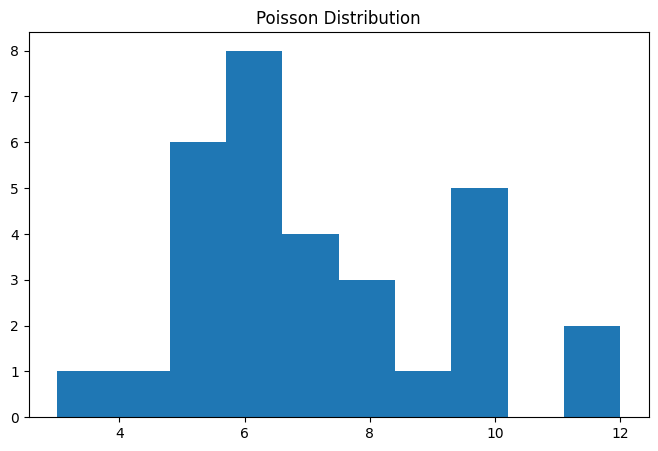

In [4]:
# Poisson Distribution
daily_txn = df.groupby('transaction_date').size()
lam = daily_txn.mean()
print('Lambda =', lam)

plt.figure(figsize=(8,5))
plt.hist(daily_txn, bins=10)
plt.title('Poisson Distribution')
plt.show()


### 🟦 <span style="color:#FFD369;">Explanation</span>

<div style="background:linear-gradient(135deg,#393E46,#222831);padding:15px;border-radius:10px;color:white;">

📌 <b style="color:#00ADB5;">Column:</b> transaction_date

🎯 <b style="color:#00ADB5;">Purpose:</b> Analyze daily transaction frequency

📊 <b style="color:#00ADB5;">Result:</b> Lambda (average daily count) calculated

🧠 <b style="color:#00ADB5;">Interpretation:</b> Checks Poisson behavior of events

</div>

Shape: 0.4749178350151927


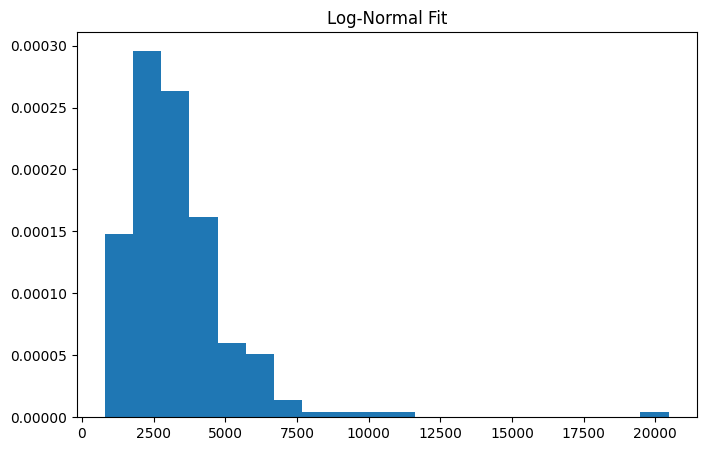

In [5]:
# Log-Normal Distribution
amounts = df['transaction_amount']
shape, loc, scale = lognorm.fit(amounts, floc=0)
print('Shape:', shape)

plt.figure(figsize=(8,5))
plt.hist(amounts, bins=20, density=True)
plt.title('Log-Normal Fit')
plt.show()


### 🟦 <span style="color:#FFD369;">Explanation</span>

<div style="background:linear-gradient(135deg,#393E46,#222831);padding:15px;border-radius:10px;color:white;">

📌 <b style="color:#00ADB5;">Column:</b> transaction_amount

🎯 <b style="color:#00ADB5;">Purpose:</b> Fit Log-Normal distribution

📊 <b style="color:#00ADB5;">Result:</b> Shape parameter estimated

🧠 <b style="color:#00ADB5;">Interpretation:</b> Studies spread of transaction amounts

</div>

In [14]:
# Power Law Distribution
a, loc, scale = powerlaw.fit(amounts)
print('Alpha:', a)


Alpha: 0.41232325172331613


### 🟦 <span style="color:#FFD369;">Explanation</span>

<div style="background:linear-gradient(135deg,#393E46,#222831);padding:15px;border-radius:10px;color:white;">

📌 <b style="color:#00ADB5;">Column:</b> transaction_amount

🎯 <b style="color:#00ADB5;">Purpose:</b> Fit Power Law distribution

📊 <b style="color:#00ADB5;">Result:</b> Alpha parameter calculated

🧠 <b style="color:#00ADB5;">Interpretation:</b> Examines heavy-tail behavior

</div>

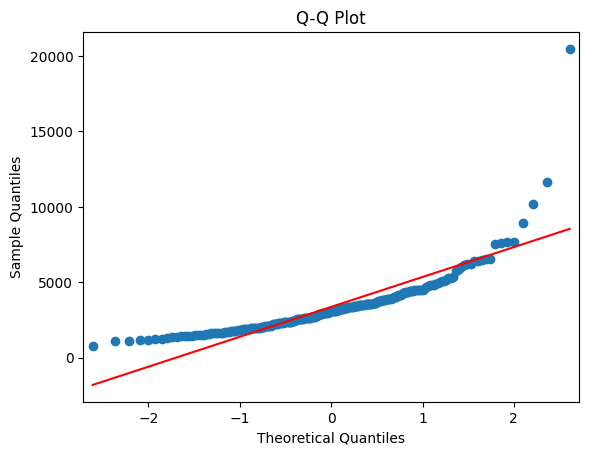

In [7]:
# Q-Q Plot
qqplot(amounts, line='s')
plt.title('Q-Q Plot')
plt.show()


### 🟦 <span style="color:#FFD369;">Explanation</span>

<div style="background:linear-gradient(135deg,#393E46,#222831);padding:15px;border-radius:10px;color:white;">

📌 <b style="color:#00ADB5;">Column:</b> transaction_amount

🎯 <b style="color:#00ADB5;">Purpose:</b> Check normality using Q-Q Plot

📊 <b style="color:#00ADB5;">Result:</b> Visual comparison generated

🧠 <b style="color:#00ADB5;">Interpretation:</b> Points near line indicate normality

</div>

Lambda: -0.18123612911845818


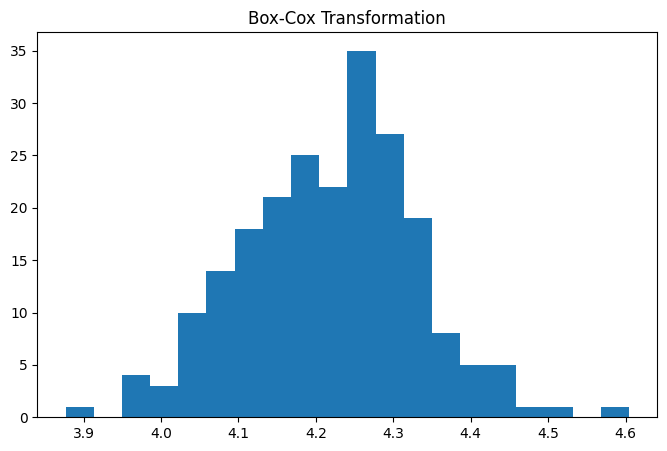

In [8]:
# Box-Cox Transform
boxcox_data, lam = stats.boxcox(amounts + 1)
print('Lambda:', lam)

plt.figure(figsize=(8,5))
plt.hist(boxcox_data, bins=20)
plt.title('Box-Cox Transformation')
plt.show()


### 🟦 <span style="color:#FFD369;">Explanation</span>

<div style="background:linear-gradient(135deg,#393E46,#222831);padding:15px;border-radius:10px;color:white;">

📌 <b style="color:#00ADB5;">Column:</b> transaction_amount

🎯 <b style="color:#00ADB5;">Purpose:</b> Apply Box-Cox transformation

📊 <b style="color:#00ADB5;">Result:</b> Optimal lambda found

🧠 <b style="color:#00ADB5;">Interpretation:</b> Helps make data more normal

</div>

In [9]:
# Z-Score Analysis
df['z_score'] = stats.zscore(amounts)
print(df[['transaction_amount','z_score']].head())


   transaction_amount   z_score
0             3821.34  0.230240
1             2781.84 -0.294446
2             4120.97  0.381477
3             6383.78  1.523626
4             2651.61 -0.360179


### 🟦 <span style="color:#FFD369;">Explanation</span>

<div style="background:linear-gradient(135deg,#393E46,#222831);padding:15px;border-radius:10px;color:white;">

📌 <b style="color:#00ADB5;">Column:</b> z_score

🎯 <b style="color:#00ADB5;">Purpose:</b> Standardize transaction amounts

📊 <b style="color:#00ADB5;">Result:</b> Z-scores generated

🧠 <b style="color:#00ADB5;">Interpretation:</b> Useful for detecting outliers

</div>

In [10]:
# Probability Amount > 5000
mu = amounts.mean()
sigma = amounts.std()

z = (5000 - mu)/sigma
probability = 1 - stats.norm.cdf(z)

print('Probability > 5000 =', probability)


Probability > 5000 = 0.20517209567554384


### 🟦 <span style="color:#FFD369;">Explanation</span>

<div style="background:linear-gradient(135deg,#393E46,#222831);padding:15px;border-radius:10px;color:white;">

📌 <b style="color:#00ADB5;">Column:</b> transaction_amount

🎯 <b style="color:#00ADB5;">Purpose:</b> Find probability above threshold

📊 <b style="color:#00ADB5;">Result:</b> Probability > 5000 calculated

🧠 <b style="color:#00ADB5;">Interpretation:</b> Measures likelihood of high-value transactions

</div>

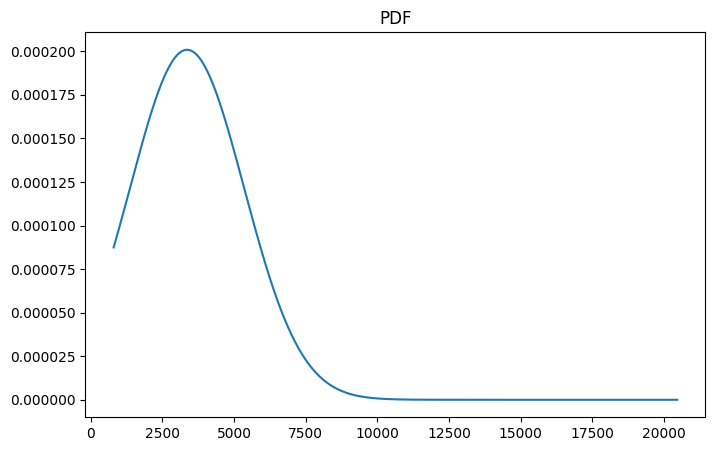

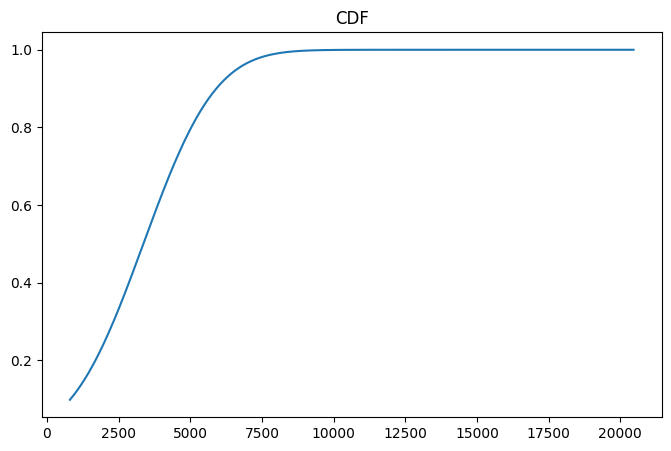

In [11]:
# PDF and CDF
x = np.linspace(amounts.min(), amounts.max(), 1000)

pdf = stats.norm.pdf(x, mu, sigma)
cdf = stats.norm.cdf(x, mu, sigma)

plt.figure(figsize=(8,5))
plt.plot(x, pdf)
plt.title('PDF')
plt.show()

plt.figure(figsize=(8,5))
plt.plot(x, cdf)
plt.title('CDF')
plt.show()


### 🟦 <span style="color:#FFD369;">Explanation</span>

<div style="background:linear-gradient(135deg,#393E46,#222831);padding:15px;border-radius:10px;color:white;">

📌 <b style="color:#00ADB5;">Column:</b> PDF & CDF

🎯 <b style="color:#00ADB5;">Purpose:</b> Visualize normal distribution

📊 <b style="color:#00ADB5;">Result:</b> PDF and CDF curves plotted

🧠 <b style="color:#00ADB5;">Interpretation:</b> Shows density and cumulative probability

</div>